# Feature Selection and PCA

In this notebook, we look at which morphological features are most useful for
distinguishing benign and malignant tumors.

We also use PCA to see whether the 30 features can be represented with fewer
dimensions while keeping most of the information.

Import Libraries

In [ ]:
# Libraries needed for data analysis and plots
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Preprocessing and PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Feature selection and model evaluation
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

## 1. Load and prepare the data

We use the original breast cancer dataset once, then create the same reproducible 80/20 stratified split used throughout the analysis.


In [ ]:
# Reproducible data loading
# Use breast_cancer.csv when it is available; otherwise rebuild the same
# Wisconsin diagnostic dataset from scikit-learn so "Run all" works cleanly.
from pathlib import Path
import numpy as np
import pandas as pd

def load_project_data():
    candidates = [
        Path("breast_cancer.csv"),
        Path("/content/breast_cancer.csv"),
        Path("/mnt/data/breast_cancer.csv"),
    ]
    for path in candidates:
        if path.exists():
            data = pd.read_csv(path)
            data.columns = data.columns.str.strip()
            if {"id", "diagnosis"}.issubset(data.columns):
                print(f"Loaded: {path}")
                return data

    from sklearn.datasets import load_breast_cancer
    raw = load_breast_cancer(as_frame=True)
    features = raw.data.copy()

    def project_name(name):
        if name.startswith("mean "):
            return name[5:].replace(" ", "_") + "_mean"
        if name.endswith(" error"):
            return name[:-6].replace(" ", "_") + "_se"
        if name.startswith("worst "):
            return name[6:].replace(" ", "_") + "_worst"
        return name.replace(" ", "_")

    features.columns = [project_name(c) for c in features.columns]
    data = features.copy()
    data.insert(0, "id", np.arange(1, len(data) + 1))
    data.insert(1, "diagnosis", np.where(raw.target.to_numpy() == 0, "M", "B"))
    print("breast_cancer.csv not found; loaded the equivalent scikit-learn dataset.")
    return data

df = load_project_data()
print("Dataset shape:", df.shape)


In [ ]:
# Separate morphology features from the diagnosis
required = {"id", "diagnosis"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"This notebook expects the original breast_cancer.csv. Missing columns: {sorted(missing)}")

X = df.drop(columns=["id", "diagnosis"])
y = df["diagnosis"].map({"B": 0, "M": 1})

if y.isna().any():
    raise ValueError("Diagnosis must contain B/M labels.")

print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Diagnosis counts (0=benign, 1=malignant):")
print(y.value_counts().sort_index())


Number of samples: 569
Number of features: 30
Diagnosis counts (0=benign, 1=malignant):
diagnosis
0    357
1    212
Name: count, dtype: int64


Separate Mean, SE and Worst features

In [ ]:
# Group the features by measurement type
mean_features = [col for col in X.columns if col.endswith("_mean")]
se_features = [col for col in X.columns if col.endswith("_se")]
worst_features = [col for col in X.columns if col.endswith("_worst")]

print("Mean features:", len(mean_features))
print("SE features:", len(se_features))
print("Worst features:", len(worst_features))

print("\nMean:", mean_features)
print("\nSE:", se_features)
print("\nWorst:", worst_features)

Mean features: 10
SE features: 10
Worst features: 10

Mean: ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean']

SE: ['radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se', 'fractal_dimension_se']

Worst: ['radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst']


Which individual features are most related to diagnosis?

In [ ]:
# Rank features by how well they separate benign and malignant cases
from sklearn.feature_selection import f_classif

f_scores, p_values = f_classif(X, y)

feature_scores = pd.DataFrame({
    "Feature": X.columns,
    "F_score": f_scores,
    "p_value": p_values
})

feature_scores = feature_scores.sort_values(
    "F_score", ascending=False
).reset_index(drop=True)

feature_scores.head(10)

,Feature,F_score,p_value
0,concave_points_worst,964.385393,1.969100e-124
1,perimeter_worst,897.944219,5.771397e-119
2,concave_points_mean,861.676020,7.101150e-116
3,radius_worst,860.781707,8.482292e-116
4,perimeter_mean,697.235272,8.436251e-101
5,area_worst,661.600206,2.828848e-97
6,radius_mean,646.981021,8.465941e-96
7,area_mean,573.060747,4.734564e-88
8,concavity_mean,533.793126,9.966556e-84
9,concavity_worst,436.691939,2.464664e-72


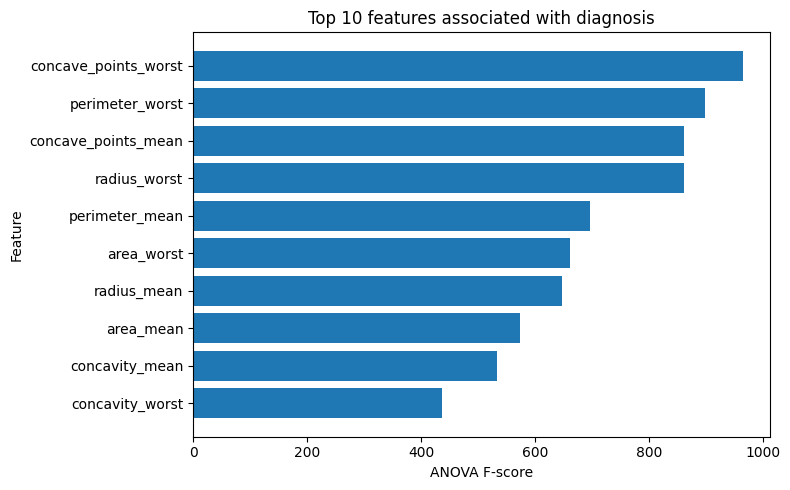

In [ ]:
# Plot the 10 features with the highest F-scores
top10 = feature_scores.head(10).sort_values("F_score")

plt.figure(figsize=(8, 5))
plt.barh(top10["Feature"], top10["F_score"])

plt.xlabel("ANOVA F-score")
plt.ylabel("Feature")
plt.title("Top 10 features associated with diagnosis")

plt.tight_layout()
plt.show()

Comparison of feature groups:


,Group,Average_F_score,Median_F_score,Max_F_score
0,mean,389.734735,423.513102,861.676020
1,se,97.800334,46.130910,268.840327
2,worst,458.311851,370.516501,964.385393


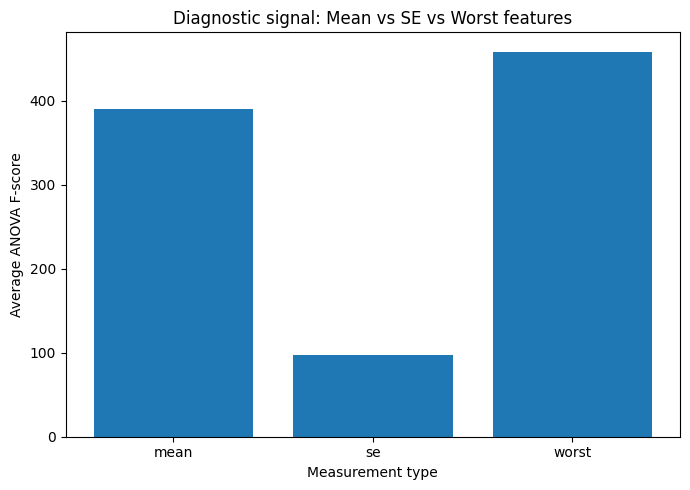

In [ ]:
# Compare MEAN vs SE vs WORST feature groups

# Use the ANOVA results already calculated in feature_scores
group_summary = []

for group in ["mean", "se", "worst"]:
    group_data = feature_scores[
        feature_scores["Feature"].str.endswith("_" + group)
    ]

    group_summary.append({
        "Group": group,
        "Average_F_score": group_data["F_score"].mean(),
        "Median_F_score": group_data["F_score"].median(),
        "Max_F_score": group_data["F_score"].max()
    })

group_summary = pd.DataFrame(group_summary)

print("Comparison of feature groups:")
display(group_summary)

# Plot average F-score
plt.figure(figsize=(7, 5))

plt.bar(
    group_summary["Group"],
    group_summary["Average_F_score"]
)

plt.xlabel("Measurement type")
plt.ylabel("Average ANOVA F-score")
plt.title("Diagnostic signal: Mean vs SE vs Worst features")

plt.tight_layout()
plt.show()

In [ ]:
# Compare mean, SE and worst for each measurement

measurements = [
    "radius", "texture", "perimeter", "area", "smoothness",
    "compactness", "concavity", "concave_points",
    "symmetry", "fractal_dimension"
]

comparison = []

for measurement in measurements:
    row = {"Measurement": measurement}

    for group in ["mean", "se", "worst"]:
        feature = f"{measurement}_{group}"

        score = feature_scores.loc[
            feature_scores["Feature"] == feature, "F_score"
        ].values[0]

        row[group] = score

    comparison.append(row)

comparison_df = pd.DataFrame(comparison)

comparison_df

,Measurement,mean,se,worst
0,radius,646.981021,268.840327,860.781707
1,texture,118.096059,0.039095,149.596905
2,perimeter,697.235272,253.897392,897.944219
3,area,573.060747,243.651586,661.600206
4,smoothness,83.651123,2.557968,122.472880
5,compactness,313.233079,53.247339,304.341063
6,concavity,533.793126,39.014482,436.691939
7,concave_points,861.676020,113.262760,964.385393
8,symmetry,69.527444,0.024117,118.860232
9,fractal_dimension,0.093459,3.468275,66.443961


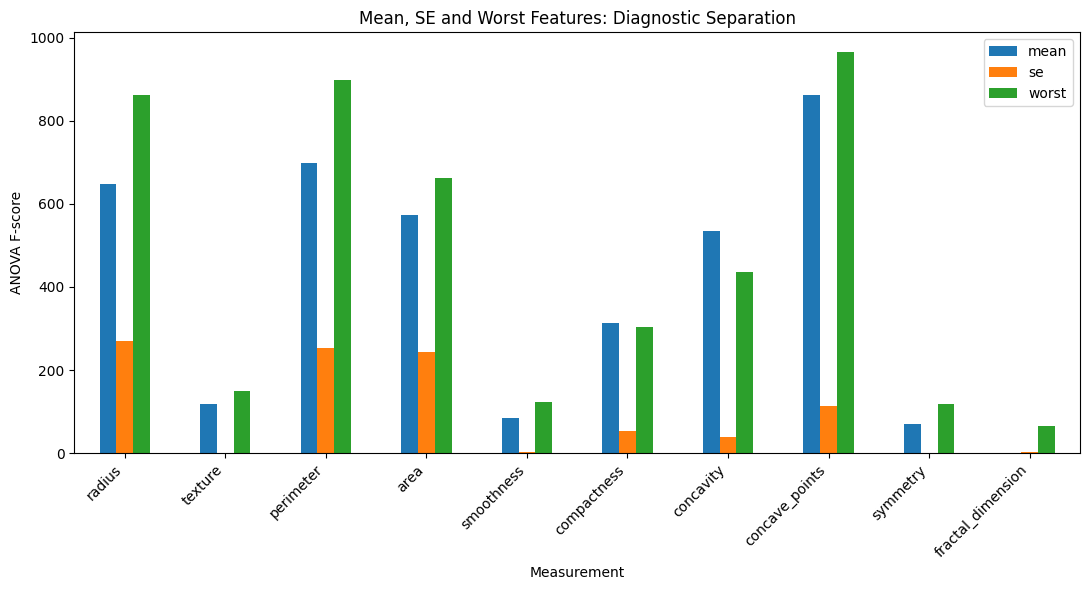

In [ ]:
# Compare the three versions of each measurement

comparison_df.set_index("Measurement").plot(
    kind="bar",
    figsize=(11, 6)
)

plt.xlabel("Measurement")
plt.ylabel("ANOVA F-score")
plt.title("Mean, SE and Worst Features: Diagnostic Separation")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [ ]:
# Create one reproducible train/test split for all supervised comparisons
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# Keep data frames with the target for convenient inspection
train_df = X_train.copy()
train_df["target"] = y_train
test_df = X_test.copy()
test_df["target"] = y_test

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Train target counts:\n", y_train.value_counts().sort_index())
print("Test target counts:\n", y_test.value_counts().sort_index())


Train shape: (455, 31)
Test shape: (114, 31)
Train target counts:
 diagnosis
0    285
1    170
Name: count, dtype: int64
Test target counts:
 diagnosis
0    72
1    42
Name: count, dtype: int64


In [ ]:
# The same split is used for Mean, SE, Worst and all-feature analyses below.
# This keeps the comparison fair and avoids depending on temporary Colab filenames.
print("Predictor columns:", X_train.shape[1])
print("Train samples:", len(X_train), "| Test samples:", len(X_test))


Predictor columns: 30
Train samples: 455 | Test samples: 114


In [ ]:
# Separate Mean, SE and Worst feature groups
mean_features = [c for c in X.columns if c.endswith("_mean")]
se_features = [c for c in X.columns if c.endswith("_se")]
worst_features = [c for c in X.columns if c.endswith("_worst")]

X_train_mean, X_test_mean = X_train[mean_features], X_test[mean_features]
X_train_se, X_test_se = X_train[se_features], X_test[se_features]
X_train_worst, X_test_worst = X_train[worst_features], X_test[worst_features]

print("Mean:", X_train_mean.shape, X_test_mean.shape)
print("SE:", X_train_se.shape, X_test_se.shape)
print("Worst:", X_train_worst.shape, X_test_worst.shape)


Mean: (455, 10) (114, 10)
SE: (455, 10) (114, 10)
Worst: (455, 10) (114, 10)


In [ ]:
# Quick check: all three groups should contain 10 features
print("Mean features:", len(mean_features))
print("SE features:", len(se_features))
print("Worst features:", len(worst_features))


Mean features: 10
SE features: 10
Worst features: 10


In [ ]:
# Check the target distribution used for modelling
print("Training target counts:")
print(y_train.value_counts().sort_index())


Training target counts:
diagnosis
0    285
1    170
Name: count, dtype: int64


In [ ]:
# Test Mean, SE and Worst features separately

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

# Target column
y_train = train_df["target"]
y_test = test_df["target"]

groups = {
    "Mean": (X_train_mean, X_test_mean),
    "SE": (X_train_se, X_test_se),
    "Worst": (X_train_worst, X_test_worst)
}

results = []

for name, (Xtr, Xte) in groups.items():

    # Scale using training data only
    scaler = StandardScaler()
    Xtr_scaled = scaler.fit_transform(Xtr)
    Xte_scaled = scaler.transform(Xte)

    # Train the same model for each feature group
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(Xtr_scaled, y_train)

    # Test on unseen data
    predictions = model.predict(Xte_scaled)
    probabilities = model.predict_proba(Xte_scaled)[:, 1]

    results.append({
        "Feature group": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "ROC_AUC": roc_auc_score(y_test, probabilities)
    })

results_df = pd.DataFrame(results)
results_df

,Feature group,Accuracy,ROC_AUC
0,Mean,0.929825,0.984127
1,SE,0.885965,0.965608
2,Worst,0.991228,0.997024


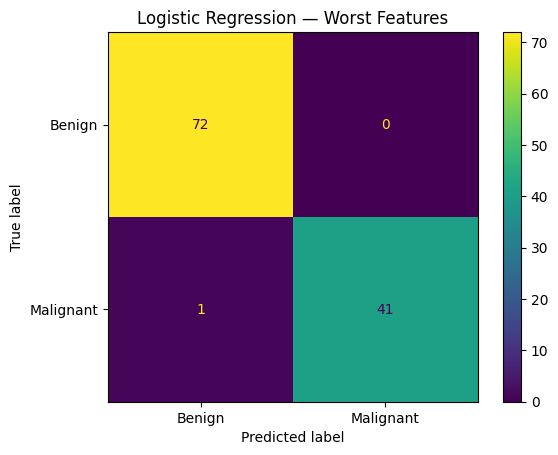

In [ ]:
# Confusion matrix for Worst features

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Scale Worst features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_worst)
X_test_scaled = scaler.transform(X_test_worst)

# Train model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Malignant"]
).plot()

plt.title("Logistic Regression — Worst Features")
plt.show()

In [ ]:
# Compare feature groups using Random Forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

rf_results = []

for name, (Xtr, Xte) in groups.items():

    model = RandomForestClassifier(
        n_estimators=500,
        random_state=42
    )

    model.fit(Xtr, y_train)

    predictions = model.predict(Xte)
    probabilities = model.predict_proba(Xte)[:, 1]

    rf_results.append({
        "Feature group": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "ROC_AUC": roc_auc_score(y_test, probabilities)
    })

rf_results_df = pd.DataFrame(rf_results)
rf_results_df


,Feature group,Accuracy,ROC_AUC
0,Mean,0.938596,0.986442
1,SE,0.929825,0.961640
2,Worst,0.973684,0.997354


In [ ]:
# Compare Logistic Regression and Random Forest

comparison_models = results_df.merge(
    rf_results_df,
    on="Feature group",
    suffixes=("_LogReg", "_RF")
)

comparison_models

,Feature group,Accuracy_LogReg,ROC_AUC_LogReg,Accuracy_RF,ROC_AUC_RF
0,Mean,0.929825,0.984127,0.938596,0.986442
1,SE,0.885965,0.965608,0.929825,0.961640
2,Worst,0.991228,0.997024,0.973684,0.997354


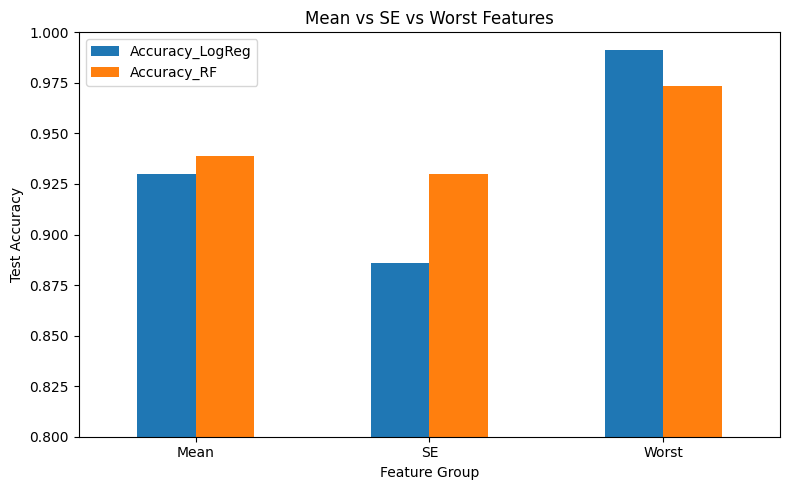

In [ ]:
# Compare accuracy across feature groups

plot_df = comparison_models[
    ["Feature group", "Accuracy_LogReg", "Accuracy_RF"]
].set_index("Feature group")

plot_df.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.ylabel("Test Accuracy")
plt.xlabel("Feature Group")
plt.title("Mean vs SE vs Worst Features")
plt.ylim(0.80, 1.00)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

ANOVA: Worst measurements generally showed stronger individual diagnostic separation.
Prediction: Using only the 10 Worst features gave the highest test accuracy for both Logistic Regression and Random Forest.

In [ ]:
# Prepare data for PCA

from sklearn.preprocessing import StandardScaler

# Use all 30 morphology features
feature_cols = mean_features + se_features + worst_features

X_train_all = train_df[feature_cols]
X_test_all = test_df[feature_cols]

# Standardize the features
scaler_pca = StandardScaler()

X_train_scaled = scaler_pca.fit_transform(X_train_all)
X_test_scaled = scaler_pca.transform(X_test_all)

print("Training data:", X_train_scaled.shape)
print("Test data:", X_test_scaled.shape)

Training data: (455, 30)
Test data: (114, 30)


In [ ]:
# Run PCA

from sklearn.decomposition import PCA

# Create and fit PCA using training data only
pca = PCA()
X_train_pca = pca.fit_transform(X_train_scaled)

# Apply the same PCA transformation to test data
X_test_pca = pca.transform(X_test_scaled)

# Variance explained by each component
explained_variance = pca.explained_variance_ratio_

for i in range(10):
    print(
        f"PC{i+1}: {explained_variance[i]*100:.2f}%"
    )

print(
    "\nVariance explained by first 2 PCs:",
    round(explained_variance[:2].sum() * 100, 2),
    "%"
)

PC1: 44.59%
PC2: 18.55%
PC3: 9.58%
PC4: 6.59%
PC5: 5.62%
PC6: 3.99%
PC7: 2.21%
PC8: 1.61%
PC9: 1.28%
PC10: 1.17%

Variance explained by first 2 PCs: 63.14 %


In [ ]:
# Cumulative explained variance

import numpy as np

cumulative_variance = np.cumsum(explained_variance)

pcs_90 = np.argmax(cumulative_variance >= 0.90) + 1
pcs_95 = np.argmax(cumulative_variance >= 0.95) + 1

print("PCs needed for 90% variance:", pcs_90)
print("PCs needed for 95% variance:", pcs_95)

PCs needed for 90% variance: 7
PCs needed for 95% variance: 10


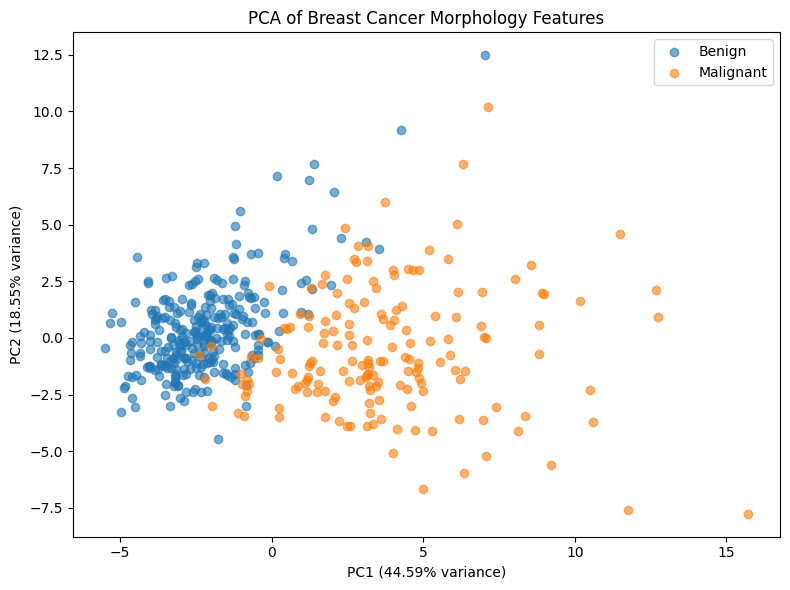

In [ ]:
# PCA visualization

plt.figure(figsize=(8, 6))

# Benign samples
plt.scatter(
    X_train_pca[y_train.values == 0, 0],
    X_train_pca[y_train.values == 0, 1],
    label="Benign",
    alpha=0.6
)

# Malignant samples
plt.scatter(
    X_train_pca[y_train.values == 1, 0],
    X_train_pca[y_train.values == 1, 1],
    label="Malignant",
    alpha=0.6
)

plt.xlabel("PC1 (44.59% variance)")
plt.ylabel("PC2 (18.55% variance)")
plt.title("PCA of Breast Cancer Morphology Features")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# PCA using only Worst features

# Standardize the 10 Worst features
scaler_worst = StandardScaler()

X_train_worst_scaled = scaler_worst.fit_transform(X_train_worst)
X_test_worst_scaled = scaler_worst.transform(X_test_worst)

# Run PCA
pca_worst = PCA()

X_train_pca_worst = pca_worst.fit_transform(X_train_worst_scaled)
X_test_pca_worst = pca_worst.transform(X_test_worst_scaled)

# Variance explained
worst_variance = pca_worst.explained_variance_ratio_

print("PC1:", round(worst_variance[0] * 100, 2), "%")
print("PC2:", round(worst_variance[1] * 100, 2), "%")
print(
    "PC1 + PC2:",
    round(worst_variance[:2].sum() * 100, 2),
    "%"
)

PC1: 57.15 %
PC2: 20.73 %
PC1 + PC2: 77.88 %


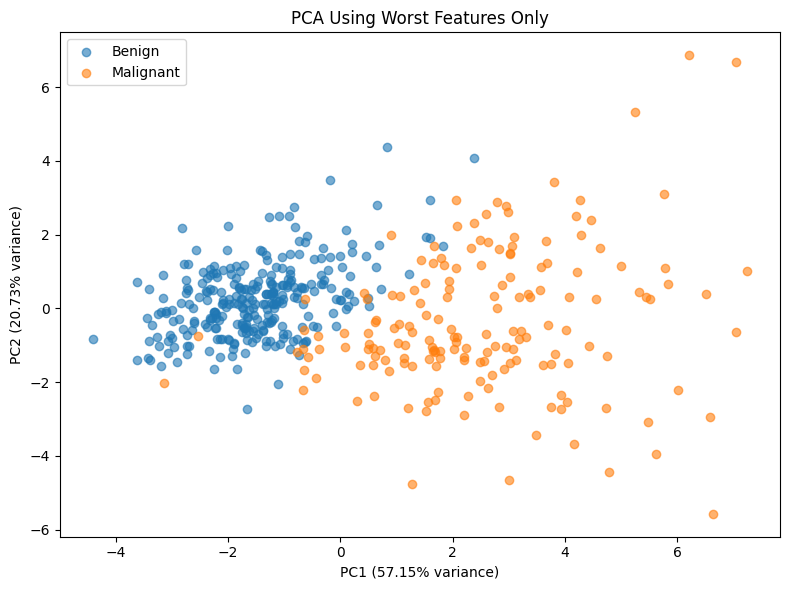

In [ ]:
# Visualize PCA using Worst features only

plt.figure(figsize=(8, 6))

plt.scatter(
    X_train_pca_worst[y_train.values == 0, 0],
    X_train_pca_worst[y_train.values == 0, 1],
    label="Benign",
    alpha=0.6
)

plt.scatter(
    X_train_pca_worst[y_train.values == 1, 0],
    X_train_pca_worst[y_train.values == 1, 1],
    label="Malignant",
    alpha=0.6
)

plt.xlabel(f"PC1 ({worst_variance[0]*100:.2f}% variance)")
plt.ylabel(f"PC2 ({worst_variance[1]*100:.2f}% variance)")
plt.title("PCA Using Worst Features Only")

plt.legend()
plt.tight_layout()
plt.show()

In [66]:
# Features contributing most to PC1

pc1_loadings = pd.DataFrame({
    "Feature": feature_cols,
    "PC1_loading": pca.components_[0]
})

pc1_loadings["Absolute_loading"] = pc1_loadings["PC1_loading"].abs()

pc1_loadings = pc1_loadings.sort_values(
    "Absolute_loading",
    ascending=False
)

pc1_loadings.head(10)

,Feature,PC1_loading,Absolute_loading
7,concave_points_mean,0.260383,0.260383
6,concavity_mean,0.257761,0.257761
27,concave_points_worst,0.249367,0.249367
5,compactness_mean,0.241928,0.241928
22,perimeter_worst,0.235494,0.235494
20,radius_worst,0.226607,0.226607
26,concavity_worst,0.226322,0.226322
2,perimeter_mean,0.225804,0.225804
23,area_worst,0.223108,0.223108
3,area_mean,0.219079,0.219079


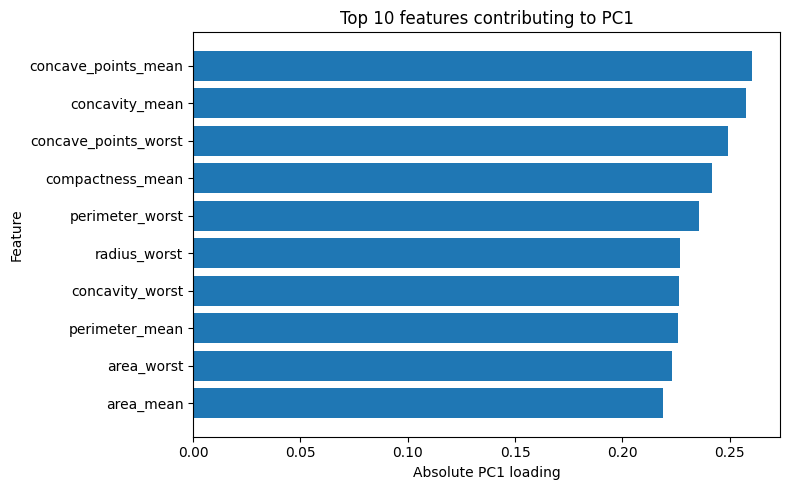

In [67]:
# Plot the features contributing most to PC1

top_pc1 = pc1_loadings.head(10).sort_values("Absolute_loading")

plt.figure(figsize=(8, 5))
plt.barh(top_pc1["Feature"], top_pc1["Absolute_loading"])

plt.xlabel("Absolute PC1 loading")
plt.ylabel("Feature")
plt.title("Top 10 features contributing to PC1")

plt.tight_layout()
plt.show()

In [68]:
# Compare PCA: all 30 features vs Worst 10 features

pca_comparison = pd.DataFrame({
    "Feature set": ["All 30 features", "Worst 10 features"],
    "PC1 (%)": [
        pca.explained_variance_ratio_[0] * 100,
        pca_worst.explained_variance_ratio_[0] * 100
    ],
    "PC1 + PC2 (%)": [
        pca.explained_variance_ratio_[:2].sum() * 100,
        pca_worst.explained_variance_ratio_[:2].sum() * 100
    ]
})

pca_comparison.round(2)

,Feature set,PC1 (%),PC1 + PC2 (%)
0,All 30 features,44.59,63.14
1,Worst 10 features,57.15,77.88


In [69]:
# Test Logistic Regression using only the first 7 PCs

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

# Keep the first 7 principal components
X_train_pca7 = X_train_pca[:, :7]
X_test_pca7 = X_test_pca[:, :7]

# Train the model
pca_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

pca_model.fit(X_train_pca7, y_train)

# Test on unseen data
pca_predictions = pca_model.predict(X_test_pca7)
pca_probabilities = pca_model.predict_proba(X_test_pca7)[:, 1]

print(
    "Accuracy:",
    round(accuracy_score(y_test, pca_predictions), 4)
)

print(
    "ROC AUC:",
    round(roc_auc_score(y_test, pca_probabilities), 4)
)

Accuracy: 0.9737
ROC AUC: 0.9967


In [70]:
# Final comparison of feature representations

# Logistic Regression using all 30 original features
full_model = LogisticRegression(max_iter=1000, random_state=42)
full_model.fit(X_train_scaled, y_train)

full_pred = full_model.predict(X_test_scaled)
full_prob = full_model.predict_proba(X_test_scaled)[:, 1]

# Results
final_comparison = pd.DataFrame({
    "Feature representation": [
        "All 30 features",
        "Worst 10 features",
        "PCA - 7 components"
    ],
    "Accuracy": [
        accuracy_score(y_test, full_pred),
        results_df.loc[
            results_df["Feature group"] == "Worst", "Accuracy"
        ].iloc[0],
        accuracy_score(y_test, pca_predictions)
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, full_prob),
        results_df.loc[
            results_df["Feature group"] == "Worst", "ROC_AUC"
        ].iloc[0],
        roc_auc_score(y_test, pca_probabilities)
    ]
})

final_comparison.round(4)

,Feature representation,Accuracy,ROC_AUC
0,All 30 features,0.9649,0.9960
1,Worst 10 features,0.9912,0.9970
2,PCA - 7 components,0.9737,0.9967


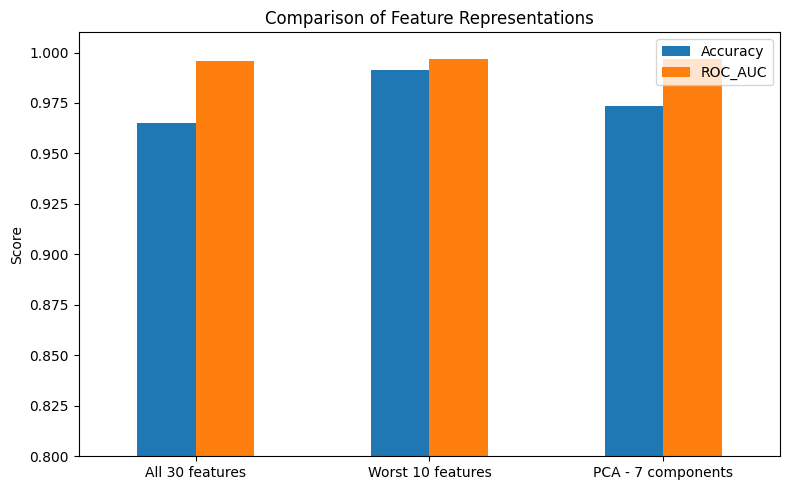

In [71]:
# Final comparison of feature representations

plot_results = final_comparison.set_index(
    "Feature representation"
)[["Accuracy", "ROC_AUC"]]

plot_results.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.ylabel("Score")
plt.xlabel("")
plt.title("Comparison of Feature Representations")
plt.ylim(0.80, 1.01)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Final Conclusion

Feature selection and PCA showed that the 30 morphology measurements contain substantial redundancy.

PCA on all 30 features showed that the first two principal components explained 63.14% of the total variance, while only 7 components were required to retain approximately 90% of the variance. Logistic Regression using these 7 components achieved 97.37% test accuracy with a ROC-AUC of 0.9967, compared with 96.49% accuracy and 0.9960 ROC-AUC when using all 30 original features.

The Worst feature group was particularly informative. Using only the 10 Worst measurements produced 99.12% accuracy and a ROC-AUC of 0.9970 on the same held-out test set. PCA of these 10 features was also more concentrated, with PC1 explaining 57.15% and the first two components together explaining 77.88% of their variance.

The PCA loading analysis showed that the dominant variation was strongly influenced by features related to concave points, concavity, compactness, radius, perimeter and area. Several of these measurements were also highlighted by the earlier supervised feature analyses.

Overall, the results suggest that the full set of 30 measurements is not necessary to preserve most of the useful structure in this dataset. A smaller feature representation can retain very strong predictive performance while making the data easier to interpret.